# 04 - Análisis de Temporadas (Seasonal Analysis)

### Objetivo
Analizar el impacto de las temporadas estacionales en las ventas de DSMarket para entender cómo los ciclos de vida social y clima afectan el comportamiento de compra.

### Contexto de negocio
En retail, las ventas no solo dependen de eventos puntuales sino también de **temporadas prolongadas** que modifican los patrones de consumo:
- **Spring Break**: Período de vacaciones escolares en marzo-abril
- **Summer Vacation**: Vacaciones de verano (junio-agosto)
- **Back to School**: Regreso a clases (julio-septiembre)
- **Winter Holidays**: Temporada navideña (noviembre-diciembre)

Entender estos patrones permite:
- Planificar inventario con anticipación
- Ajustar estrategias de marketing por temporada
- Mejorar la precisión de las predicciones de ventas

### Qué se consigue al finalizar
- Cuantificación del impacto de cada temporada en las ventas
- Identificación de categorías y regiones más afectadas por cada temporada
- Recomendaciones para crear features de temporada en el modelo

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Configuración de figuras
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 2. Carga de datos procesados

In [2]:
# Cargar dataset procesado
df = pd.read_csv('/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/processed/sales_processed.csv')

# Convertir date a datetime
df['date'] = pd.to_datetime(df['date'])

# Crear variables temporales necesarias
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['year'] = df['date'].dt.year

print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Rango de fechas: {df['date'].min().date()} a {df['date'].max().date()}")

/var/folders/6r/9052dzp97n13nr25t57vnnf80000gn/T/ipykernel_1515/417770303.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/processed/sales_processed.csv')


Dataset cargado: 58,327,370 filas x 19 columnas
Rango de fechas: 2011-01-29 a 2016-04-24


## 3. Definición de temporadas

Definimos las temporadas según el calendario típico de EE.UU.:

| Temporada | Período | Descripción |
|-----------|---------|-------------|
| **Spring Break** | 1 marzo - 15 abril | Vacaciones de primavera escolares |
| **Summer Vacation** | 1 junio - 31 agosto | Vacaciones de verano |
| **Back to School** | 15 julio - 15 septiembre | Preparación regreso a clases |
| **Winter Holidays** | 15 noviembre - 31 diciembre | Temporada navideña y compras de fin de año |
| **Regular** | Resto del año | Días sin temporada especial |

**Nota:** Back to School y Summer Vacation se solapan parcialmente (15 julio - 31 agosto). En ese período asignaremos "Back_to_School" por ser más relevante para retail.

In [3]:
# Función para asignar temporada según mes y día
def asignar_temporada(row):
    month = row['month']
    day = row['day']
    
    # Winter Holidays: 15 noviembre - 31 diciembre
    if (month == 11 and day >= 15) or (month == 12):
        return 'Winter_Holidays'
    
    # Back to School: 15 julio - 15 septiembre
    if (month == 7 and day >= 15) or (month == 8) or (month == 9 and day <= 15):
        return 'Back_to_School'
    
    # Summer Vacation: 1 junio - 14 julio (antes de Back to School)
    if (month == 6) or (month == 7 and day < 15):
        return 'Summer_Vacation'
    
    # Spring Break: 1 marzo - 15 abril
    if (month == 3) or (month == 4 and day <= 15):
        return 'Spring_Break'
    
    # Resto: Regular
    return 'Regular'

# Aplicar función
print("Asignando temporadas... (puede tardar unos segundos)")
df['season'] = df.apply(asignar_temporada, axis=1)
print("Temporadas asignadas correctamente")

Asignando temporadas... (puede tardar unos segundos)
Temporadas asignadas correctamente


In [4]:
# Verificar asignación de temporadas
print("="*60)
print("DISTRIBUCIÓN DE REGISTROS POR TEMPORADA")
print("="*60)

registros_por_temporada = df['season'].value_counts()
print(registros_por_temporada)

print("\nPorcentaje de registros:")
print((registros_por_temporada / len(df) * 100).round(2))

DISTRIBUCIÓN DE REGISTROS POR TEMPORADA
season
Regular            26434830
Back_to_School      9604350
Spring_Break        8415240
Winter_Holidays     7165150
Summer_Vacation     6707800
Name: count, dtype: int64

Porcentaje de registros:
season
Regular           45.32
Back_to_School    16.47
Spring_Break      14.43
Winter_Holidays   12.28
Summer_Vacation   11.50
Name: count, dtype: float64


In [5]:
# Verificar días únicos por temporada
print("="*60)
print("DÍAS ÚNICOS POR TEMPORADA")
print("="*60)

dias_por_temporada = df.groupby('season')['date'].nunique()
print(dias_por_temporada)

print(f"\nTotal días: {df['date'].nunique()}")
print(f"Suma de días por temporada: {dias_por_temporada.sum()}")

DÍAS ÚNICOS POR TEMPORADA
season
Back_to_School     315
Regular            867
Spring_Break       276
Summer_Vacation    220
Winter_Holidays    235
Name: date, dtype: int64

Total días: 1913
Suma de días por temporada: 1913


## 4. Análisis global por temporada

Comparamos las ventas promedio entre temporadas para identificar cuáles tienen mayor impacto.

In [6]:
# Crear serie de ventas diarias con temporada
ventas_diarias = df.groupby(['date', 'season'])['sales'].sum().reset_index()
ventas_diarias.columns = ['date', 'season', 'sales']

print(f"Serie de ventas diarias: {len(ventas_diarias)} registros")
ventas_diarias.head()

Serie de ventas diarias: 1913 registros


,date,season,sales
0,2011-01-29,Regular,32631
1,2011-01-30,Regular,31749
2,2011-01-31,Regular,23783
3,2011-02-01,Regular,25412
4,2011-02-02,Regular,19146


In [7]:
# Estadísticas por temporada
print("="*60)
print("ESTADÍSTICAS DE VENTAS DIARIAS POR TEMPORADA")
print("="*60)

stats_temporada = ventas_diarias.groupby('season')['sales'].agg([
    'count', 'mean', 'std', 'min', 'max', 'median'
]).round(0)

# Calcular diferencia vs Regular
media_regular = stats_temporada.loc['Regular', 'mean']
stats_temporada['diff_vs_regular_%'] = ((stats_temporada['mean'] / media_regular) - 1) * 100

print(stats_temporada.sort_values('mean', ascending=False))

ESTADÍSTICAS DE VENTAS DIARIAS POR TEMPORADA
                 count     mean     std    min    max   median  \
season                                                           
Summer_Vacation    220 35739.00 6867.00  19800  54154 35997.00   
Back_to_School     315 35573.00 7103.00  20350  51961 35079.00   
Spring_Break       276 35018.00 7773.00  18854  57218 34389.00   
Regular            867 33837.00 7228.00  17929  55040 33059.00   
Winter_Holidays    235 32448.00 7469.00     11  49755 32605.00   

                 diff_vs_regular_%  
season                              
Summer_Vacation               5.62  
Back_to_School                5.13  
Spring_Break                  3.49  
Regular                       0.00  
Winter_Holidays              -4.10  


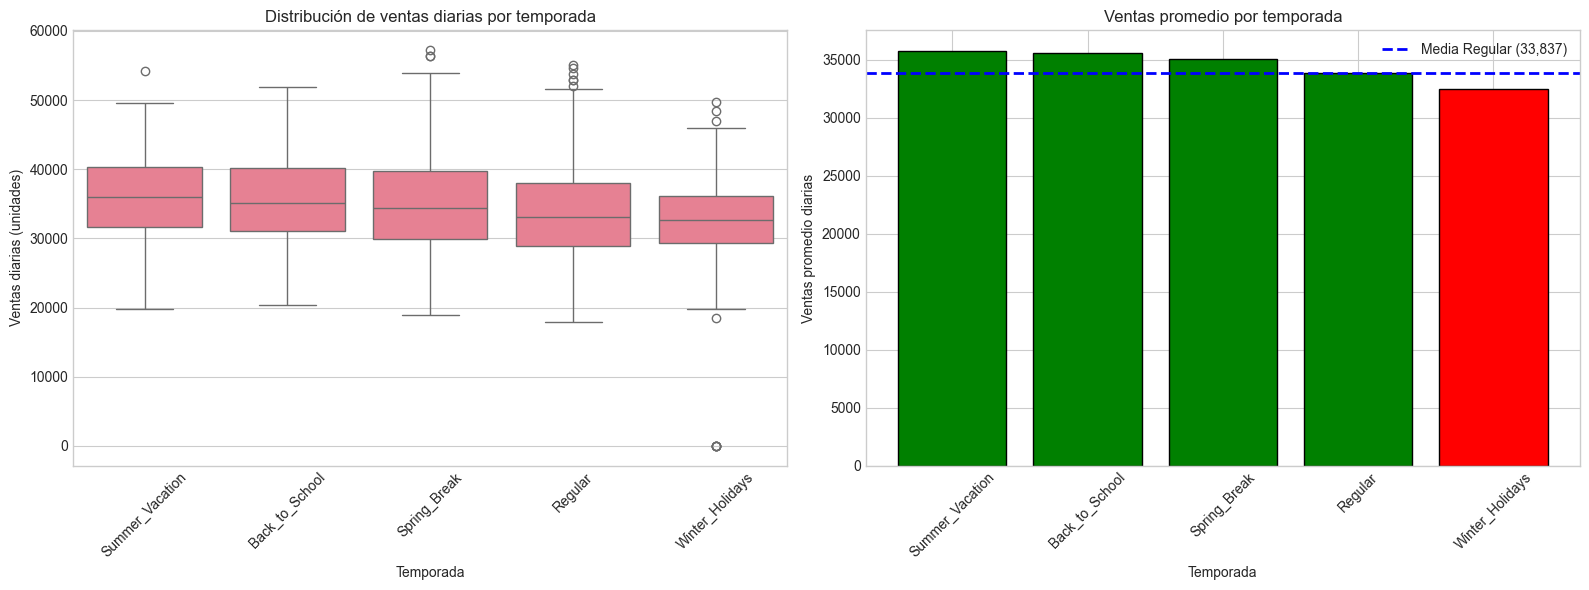

In [8]:
# Visualización: Boxplot de ventas por temporada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Orden de temporadas por ventas medias
orden_temporadas = stats_temporada.sort_values('mean', ascending=False).index.tolist()

# Boxplot
sns.boxplot(data=ventas_diarias, x='season', y='sales', order=orden_temporadas, ax=axes[0])
axes[0].set_xlabel('Temporada')
axes[0].set_ylabel('Ventas diarias (unidades)')
axes[0].set_title('Distribución de ventas diarias por temporada')
axes[0].tick_params(axis='x', rotation=45)

# Barplot con media
ventas_media = ventas_diarias.groupby('season')['sales'].mean().reindex(orden_temporadas)
colores = ['green' if x > media_regular else 'red' if x < media_regular else 'gray' for x in ventas_media]
axes[1].bar(ventas_media.index, ventas_media.values, color=colores, edgecolor='black')
axes[1].axhline(y=media_regular, color='blue', linestyle='--', linewidth=2, label=f'Media Regular ({media_regular:,.0f})')
axes[1].set_xlabel('Temporada')
axes[1].set_ylabel('Ventas promedio diarias')
axes[1].set_title('Ventas promedio por temporada')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# Test estadístico: ¿Las diferencias son significativas?
print("="*60)
print("TEST ANOVA: ¿EXISTEN DIFERENCIAS SIGNIFICATIVAS ENTRE TEMPORADAS?")
print("="*60)

# Preparar grupos para ANOVA
grupos = [ventas_diarias[ventas_diarias['season'] == s]['sales'].values for s in ventas_diarias['season'].unique()]
f_stat, p_value = stats.f_oneway(*grupos)

print(f"Estadístico F: {f_stat:.2f}")
print(f"P-valor: {p_value:.2e}")

if p_value < 0.05:
    print("\n✓ SÍ existen diferencias significativas entre temporadas (p < 0.05)")
else:
    print("\n✗ NO existen diferencias significativas entre temporadas (p >= 0.05)")

TEST ANOVA: ¿EXISTEN DIFERENCIAS SIGNIFICATIVAS ENTRE TEMPORADAS?
Estadístico F: 9.89
P-valor: 6.36e-08

✓ SÍ existen diferencias significativas entre temporadas (p < 0.05)


## 5. Análisis Spring Break (1 marzo - 15 abril)

Período de vacaciones escolares de primavera. Analizamos su impacto en detalle.

In [10]:
# Filtrar datos de Spring Break
df_spring = df[df['season'] == 'Spring_Break'].copy()
ventas_spring = ventas_diarias[ventas_diarias['season'] == 'Spring_Break'].copy()

print("="*60)
print("SPRING BREAK - ESTADÍSTICAS GENERALES")
print("="*60)
print(f"Días totales: {ventas_spring['date'].nunique()}")
print(f"Ventas promedio diarias: {ventas_spring['sales'].mean():,.0f}")
print(f"Diferencia vs Regular: {((ventas_spring['sales'].mean() / media_regular) - 1) * 100:.1f}%")

SPRING BREAK - ESTADÍSTICAS GENERALES
Días totales: 276
Ventas promedio diarias: 35,018
Diferencia vs Regular: 3.5%


SPRING BREAK - VENTAS POR AÑO
      media_diaria    total  dias
year                             
2011      25163.93  1157541    46
2012      32571.20  1498275    46
2013      36446.57  1676542    46
2014      36997.41  1701881    46
2015      36816.63  1693565    46
2016      42112.02  1937153    46


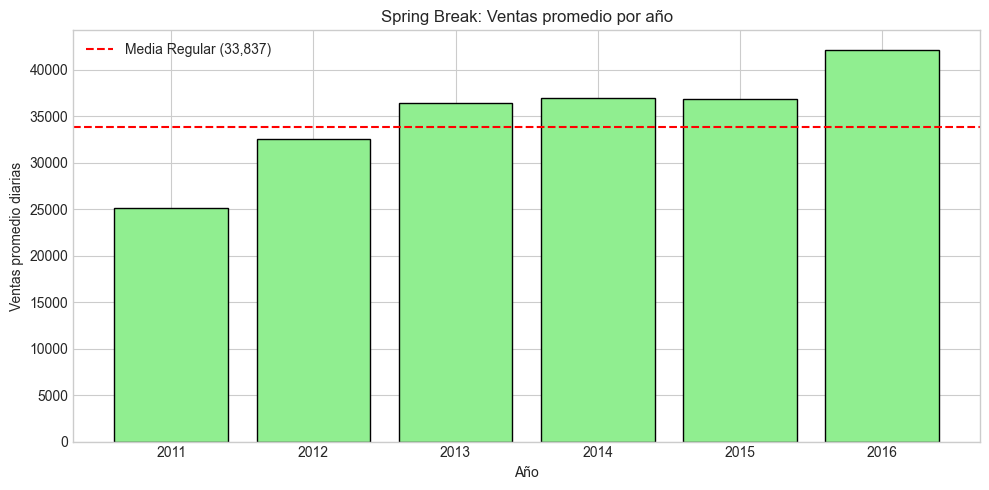

In [11]:
# Spring Break: Consistencia año a año
print("="*60)
print("SPRING BREAK - VENTAS POR AÑO")
print("="*60)

ventas_spring['year'] = ventas_spring['date'].dt.year
spring_por_año = ventas_spring.groupby('year')['sales'].agg(['mean', 'sum', 'count'])
spring_por_año.columns = ['media_diaria', 'total', 'dias']

print(spring_por_año)

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(spring_por_año.index.astype(str), spring_por_año['media_diaria'], color='lightgreen', edgecolor='black')
ax.axhline(y=media_regular, color='red', linestyle='--', label=f'Media Regular ({media_regular:,.0f})')
ax.set_xlabel('Año')
ax.set_ylabel('Ventas promedio diarias')
ax.set_title('Spring Break: Ventas promedio por año')
ax.legend()
plt.tight_layout()
plt.show()

SPRING BREAK - VENTAS POR CATEGORÍA
               Spring_Break  Regular  Diferencia_%
category                                          
ACCESORIES          3283.00  3206.00          2.40
HOME_&_GARDEN       7774.70  7485.20          3.90
SUPERMARKET        23960.20 23146.30          3.50


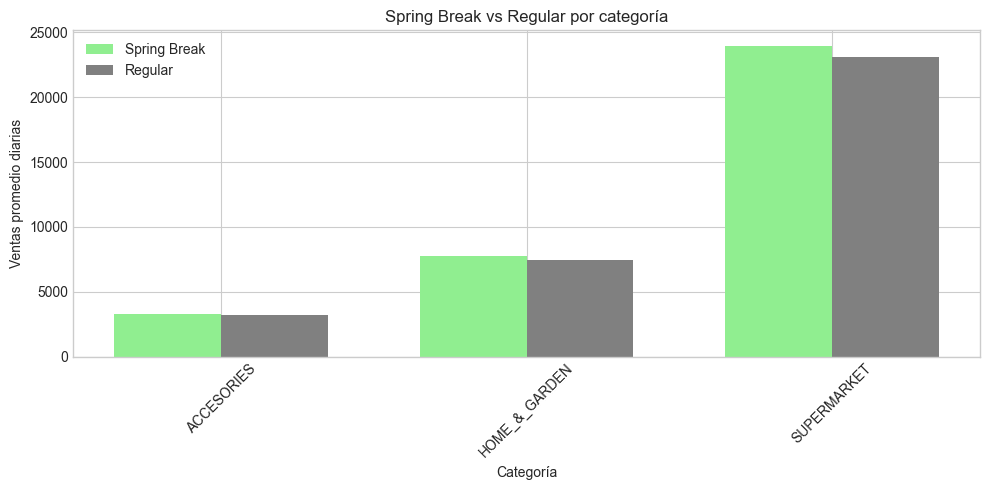

In [12]:
# Spring Break: Impacto por categoría
print("="*60)
print("SPRING BREAK - VENTAS POR CATEGORÍA")
print("="*60)

# Ventas diarias por categoría en Spring Break
spring_por_cat = df_spring.groupby(['date', 'category'])['sales'].sum().reset_index()
spring_cat_media = spring_por_cat.groupby('category')['sales'].mean()

# Comparar con Regular
df_regular = df[df['season'] == 'Regular']
regular_por_cat = df_regular.groupby(['date', 'category'])['sales'].sum().reset_index()
regular_cat_media = regular_por_cat.groupby('category')['sales'].mean()

comparacion_cat = pd.DataFrame({
    'Spring_Break': spring_cat_media,
    'Regular': regular_cat_media
})
comparacion_cat['Diferencia_%'] = ((comparacion_cat['Spring_Break'] / comparacion_cat['Regular']) - 1) * 100

print(comparacion_cat.round(1))

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparacion_cat))
width = 0.35
ax.bar(x - width/2, comparacion_cat['Spring_Break'], width, label='Spring Break', color='lightgreen')
ax.bar(x + width/2, comparacion_cat['Regular'], width, label='Regular', color='gray')
ax.set_xlabel('Categoría')
ax.set_ylabel('Ventas promedio diarias')
ax.set_title('Spring Break vs Regular por categoría')
ax.set_xticks(x)
ax.set_xticklabels(comparacion_cat.index, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Spring Break: Impacto por región
print("="*60)
print("SPRING BREAK - VENTAS POR REGIÓN")
print("="*60)

spring_por_reg = df_spring.groupby(['date', 'region'])['sales'].sum().reset_index()
spring_reg_media = spring_por_reg.groupby('region')['sales'].mean()

regular_por_reg = df_regular.groupby(['date', 'region'])['sales'].sum().reset_index()
regular_reg_media = regular_por_reg.groupby('region')['sales'].mean()

comparacion_reg = pd.DataFrame({
    'Spring_Break': spring_reg_media,
    'Regular': regular_reg_media
})
comparacion_reg['Diferencia_%'] = ((comparacion_reg['Spring_Break'] / comparacion_reg['Regular']) - 1) * 100

print(comparacion_reg.round(1))

SPRING BREAK - VENTAS POR REGIÓN
              Spring_Break  Regular  Diferencia_%
region                                           
Boston            10035.20  9684.70          3.60
New York          15081.50 14771.50          2.10
Philadelphia       9901.20  9381.20          5.50


## 6. Análisis Summer Vacation (1 junio - 14 julio)

Período de vacaciones de verano antes del inicio de Back to School.

In [14]:
# Filtrar datos de Summer Vacation
df_summer = df[df['season'] == 'Summer_Vacation'].copy()
ventas_summer = ventas_diarias[ventas_diarias['season'] == 'Summer_Vacation'].copy()

print("="*60)
print("SUMMER VACATION - ESTADÍSTICAS GENERALES")
print("="*60)
print(f"Días totales: {ventas_summer['date'].nunique()}")
print(f"Ventas promedio diarias: {ventas_summer['sales'].mean():,.0f}")
print(f"Diferencia vs Regular: {((ventas_summer['sales'].mean() / media_regular) - 1) * 100:.1f}%")

SUMMER VACATION - ESTADÍSTICAS GENERALES
Días totales: 220
Ventas promedio diarias: 35,739
Diferencia vs Regular: 5.6%


SUMMER VACATION - VENTAS POR AÑO
      media_diaria    total  dias
year                             
2011      25894.66  1139365    44
2012      36734.25  1616307    44
2013      38599.66  1698385    44
2014      37998.02  1671913    44
2015      39468.86  1736630    44


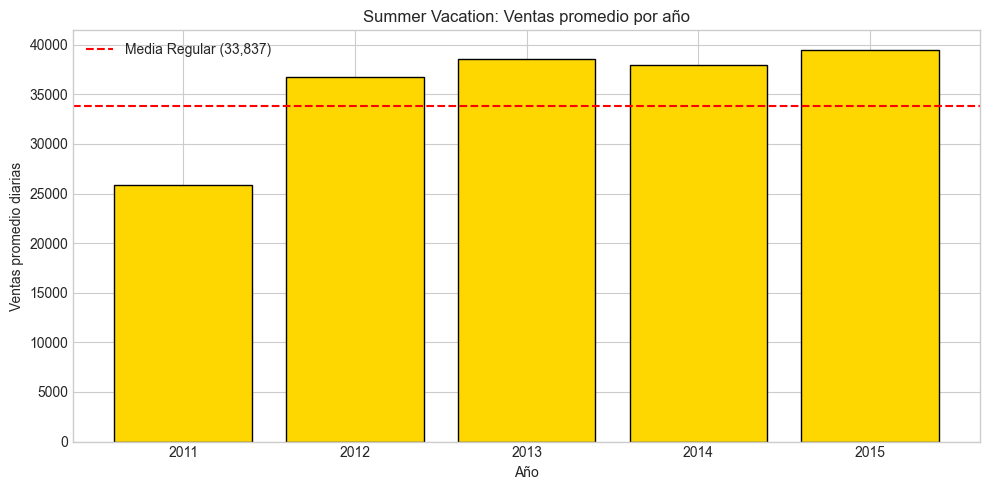

In [15]:
# Summer Vacation: Consistencia año a año
print("="*60)
print("SUMMER VACATION - VENTAS POR AÑO")
print("="*60)

ventas_summer['year'] = ventas_summer['date'].dt.year
summer_por_año = ventas_summer.groupby('year')['sales'].agg(['mean', 'sum', 'count'])
summer_por_año.columns = ['media_diaria', 'total', 'dias']

print(summer_por_año)

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(summer_por_año.index.astype(str), summer_por_año['media_diaria'], color='gold', edgecolor='black')
ax.axhline(y=media_regular, color='red', linestyle='--', label=f'Media Regular ({media_regular:,.0f})')
ax.set_xlabel('Año')
ax.set_ylabel('Ventas promedio diarias')
ax.set_title('Summer Vacation: Ventas promedio por año')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Summer Vacation: Impacto por categoría
print("="*60)
print("SUMMER VACATION - VENTAS POR CATEGORÍA")
print("="*60)

summer_por_cat = df_summer.groupby(['date', 'category'])['sales'].sum().reset_index()
summer_cat_media = summer_por_cat.groupby('category')['sales'].mean()

comparacion_cat_summer = pd.DataFrame({
    'Summer_Vacation': summer_cat_media,
    'Regular': regular_cat_media
})
comparacion_cat_summer['Diferencia_%'] = ((comparacion_cat_summer['Summer_Vacation'] / comparacion_cat_summer['Regular']) - 1) * 100

print(comparacion_cat_summer.round(1))

SUMMER VACATION - VENTAS POR CATEGORÍA
               Summer_Vacation  Regular  Diferencia_%
category                                             
ACCESORIES             3282.40  3206.00          2.40
HOME_&_GARDEN          7606.30  7485.20          1.60
SUPERMARKET           24850.30 23146.30          7.40


## 8. Análisis Back to School (15 julio - 15 septiembre)

Período de preparación para el regreso a clases. Uno de los más importantes para retail.

In [17]:
# Filtrar datos de Back to School
df_bts = df[df['season'] == 'Back_to_School'].copy()
ventas_bts = ventas_diarias[ventas_diarias['season'] == 'Back_to_School'].copy()

print("="*60)
print("BACK TO SCHOOL - ESTADÍSTICAS GENERALES")
print("="*60)
print(f"Días totales: {ventas_bts['date'].nunique()}")
print(f"Ventas promedio diarias: {ventas_bts['sales'].mean():,.0f}")
print(f"Diferencia vs Regular: {((ventas_bts['sales'].mean() / media_regular) - 1) * 100:.1f}%")

BACK TO SCHOOL - ESTADÍSTICAS GENERALES
Días totales: 315
Ventas promedio diarias: 35,573
Diferencia vs Regular: 5.1%


BACK TO SCHOOL - VENTAS POR AÑO
      media_diaria    total  dias
year                             
2011      26624.08  1677317    63
2012      35311.16  2224603    63
2013      38513.87  2426374    63
2014      37343.14  2352618    63
2015      40072.65  2524577    63


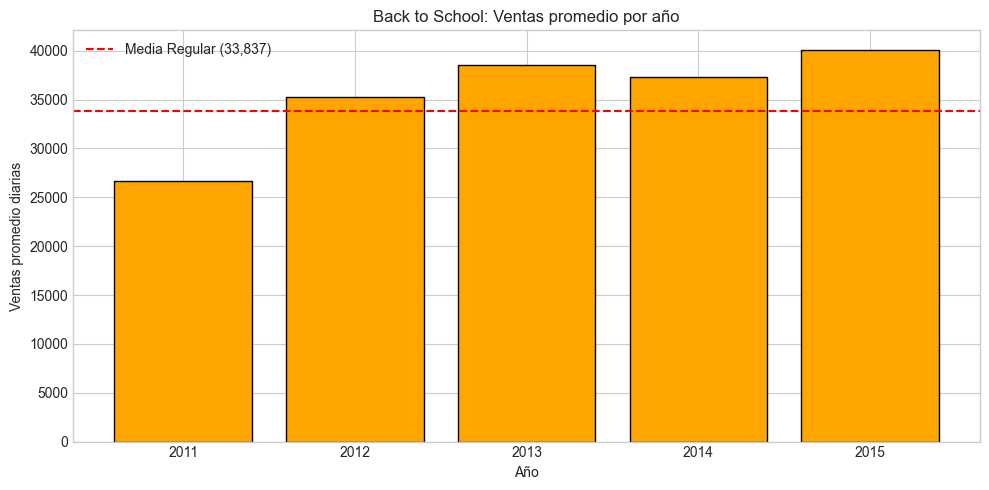

In [18]:
# Back to School: Consistencia año a año
print("="*60)
print("BACK TO SCHOOL - VENTAS POR AÑO")
print("="*60)

ventas_bts['year'] = ventas_bts['date'].dt.year
bts_por_año = ventas_bts.groupby('year')['sales'].agg(['mean', 'sum', 'count'])
bts_por_año.columns = ['media_diaria', 'total', 'dias']

print(bts_por_año)

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(bts_por_año.index.astype(str), bts_por_año['media_diaria'], color='orange', edgecolor='black')
ax.axhline(y=media_regular, color='red', linestyle='--', label=f'Media Regular ({media_regular:,.0f})')
ax.set_xlabel('Año')
ax.set_ylabel('Ventas promedio diarias')
ax.set_title('Back to School: Ventas promedio por año')
ax.legend()
plt.tight_layout()
plt.show()

BACK TO SCHOOL - VENTAS POR CATEGORÍA
               Back_to_School  Regular  Diferencia_%
category                                            
ACCESORIES            3098.70  3206.00         -3.30
HOME_&_GARDEN         7989.10  7485.20          6.70
SUPERMARKET          24485.20 23146.30          5.80


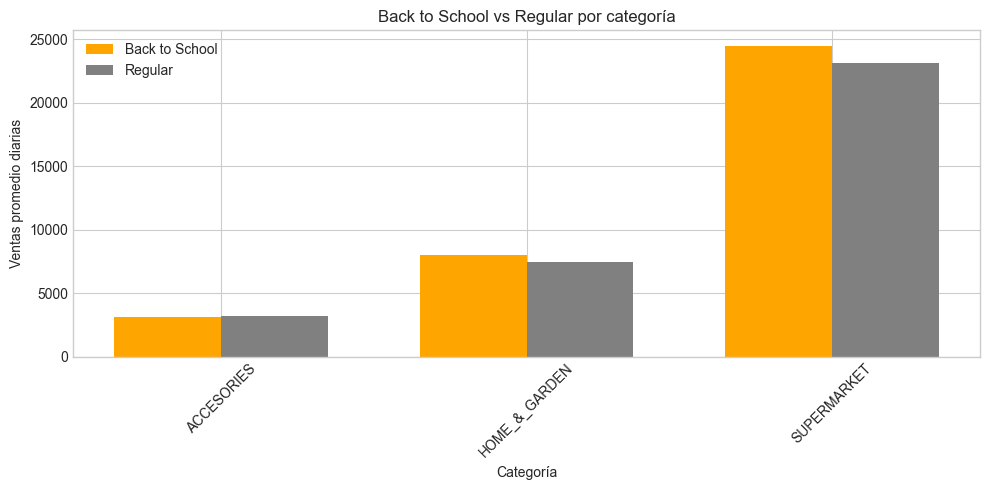

In [19]:
# Back to School: Impacto por categoría
print("="*60)
print("BACK TO SCHOOL - VENTAS POR CATEGORÍA")
print("="*60)

bts_por_cat = df_bts.groupby(['date', 'category'])['sales'].sum().reset_index()
bts_cat_media = bts_por_cat.groupby('category')['sales'].mean()

comparacion_cat_bts = pd.DataFrame({
    'Back_to_School': bts_cat_media,
    'Regular': regular_cat_media
})
comparacion_cat_bts['Diferencia_%'] = ((comparacion_cat_bts['Back_to_School'] / comparacion_cat_bts['Regular']) - 1) * 100

print(comparacion_cat_bts.round(1))

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparacion_cat_bts))
width = 0.35
ax.bar(x - width/2, comparacion_cat_bts['Back_to_School'], width, label='Back to School', color='orange')
ax.bar(x + width/2, comparacion_cat_bts['Regular'], width, label='Regular', color='gray')
ax.set_xlabel('Categoría')
ax.set_ylabel('Ventas promedio diarias')
ax.set_title('Back to School vs Regular por categoría')
ax.set_xticks(x)
ax.set_xticklabels(comparacion_cat_bts.index, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 9. Análisis Winter Holidays (15 noviembre - 31 diciembre)

Temporada navideña y de compras de fin de año. Incluye eventos como Thanksgiving, Black Friday, Cyber Monday y Christmas.

In [20]:
# Filtrar datos de Winter Holidays
df_winter = df[df['season'] == 'Winter_Holidays'].copy()
ventas_winter = ventas_diarias[ventas_diarias['season'] == 'Winter_Holidays'].copy()

print("="*60)
print("WINTER HOLIDAYS - ESTADÍSTICAS GENERALES")
print("="*60)
print(f"Días totales: {ventas_winter['date'].nunique()}")
print(f"Ventas promedio diarias: {ventas_winter['sales'].mean():,.0f}")
print(f"Diferencia vs Regular: {((ventas_winter['sales'].mean() / media_regular) - 1) * 100:.1f}%")

WINTER HOLIDAYS - ESTADÍSTICAS GENERALES
Días totales: 235
Ventas promedio diarias: 32,448
Diferencia vs Regular: -4.1%


WINTER HOLIDAYS - VENTAS POR AÑO
      media_diaria    total  dias
year                             
2011      27569.43  1295763    47
2012      31945.89  1501457    47
2013      33608.98  1579622    47
2014      33025.81  1552213    47
2015      36089.53  1696208    47


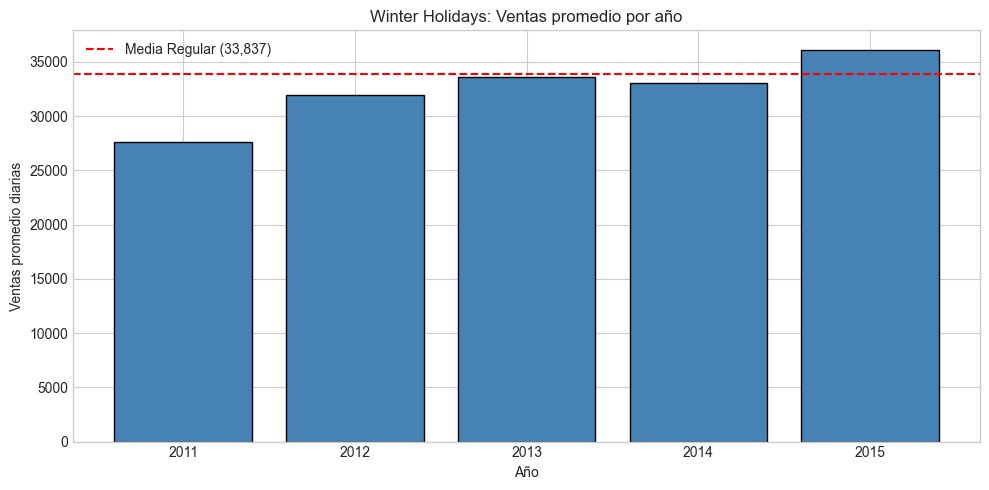

In [21]:
# Winter Holidays: Consistencia año a año
print("="*60)
print("WINTER HOLIDAYS - VENTAS POR AÑO")
print("="*60)

ventas_winter['year'] = ventas_winter['date'].dt.year
winter_por_año = ventas_winter.groupby('year')['sales'].agg(['mean', 'sum', 'count'])
winter_por_año.columns = ['media_diaria', 'total', 'dias']

print(winter_por_año)

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(winter_por_año.index.astype(str), winter_por_año['media_diaria'], color='steelblue', edgecolor='black')
ax.axhline(y=media_regular, color='red', linestyle='--', label=f'Media Regular ({media_regular:,.0f})')
ax.set_xlabel('Año')
ax.set_ylabel('Ventas promedio diarias')
ax.set_title('Winter Holidays: Ventas promedio por año')
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
# Winter Holidays: Impacto por categoría
print("="*60)
print("WINTER HOLIDAYS - VENTAS POR CATEGORÍA")
print("="*60)

winter_por_cat = df_winter.groupby(['date', 'category'])['sales'].sum().reset_index()
winter_cat_media = winter_por_cat.groupby('category')['sales'].mean()

comparacion_cat_winter = pd.DataFrame({
    'Winter_Holidays': winter_cat_media,
    'Regular': regular_cat_media
})
comparacion_cat_winter['Diferencia_%'] = ((comparacion_cat_winter['Winter_Holidays'] / comparacion_cat_winter['Regular']) - 1) * 100

print(comparacion_cat_winter.round(1))

WINTER HOLIDAYS - VENTAS POR CATEGORÍA
               Winter_Holidays  Regular  Diferencia_%
category                                             
ACCESORIES             3152.60  3206.00         -1.70
HOME_&_GARDEN          7043.70  7485.20         -5.90
SUPERMARKET           22251.60 23146.30         -3.90


In [23]:
# Winter Holidays: Desglose por evento dentro de la temporada
print("="*60)
print("WINTER HOLIDAYS - EVENTOS DENTRO DE LA TEMPORADA")
print("="*60)

eventos_winter = df_winter[df_winter['event'].notna()].groupby('event')['sales'].sum()
print("Ventas totales por evento en Winter Holidays:")
print(eventos_winter.sort_values(ascending=False))

WINTER HOLIDAYS - EVENTOS DENTRO DE LA TEMPORADA
Ventas totales por evento en Winter Holidays:
event
NewYears_Eve    180107
Cyber_Monday    152262
Black_Friday    127429
Thanksgiving    105650
Christmas           78
Name: sales, dtype: int64


## 10. Comparación entre temporadas

Resumen comparativo del impacto de cada temporada en las ventas.

In [24]:
# Tabla resumen comparativa
print("="*60)
print("RESUMEN COMPARATIVO DE TEMPORADAS")
print("="*60)

resumen = pd.DataFrame({
    'Temporada': ['Spring_Break', 'Summer_Vacation', 'Back_to_School', 'Winter_Holidays', 'Regular'],
    'Días': [
        ventas_spring['date'].nunique(),
        ventas_summer['date'].nunique(),
        ventas_bts['date'].nunique(),
        ventas_winter['date'].nunique(),
        ventas_diarias[ventas_diarias['season'] == 'Regular']['date'].nunique()
    ],
    'Ventas_Media_Diaria': [
        ventas_spring['sales'].mean(),
        ventas_summer['sales'].mean(),
        ventas_bts['sales'].mean(),
        ventas_winter['sales'].mean(),
        media_regular
    ]
})

resumen['Diferencia_vs_Regular_%'] = ((resumen['Ventas_Media_Diaria'] / media_regular) - 1) * 100
resumen = resumen.sort_values('Ventas_Media_Diaria', ascending=False)

print(resumen.round(1).to_string(index=False))

RESUMEN COMPARATIVO DE TEMPORADAS
      Temporada  Días  Ventas_Media_Diaria  Diferencia_vs_Regular_%
Summer_Vacation   220             35739.10                     5.60
 Back_to_School   315             35573.00                     5.10
   Spring_Break   276             35018.00                     3.50
        Regular   867             33837.00                     0.00
Winter_Holidays   235             32447.90                    -4.10


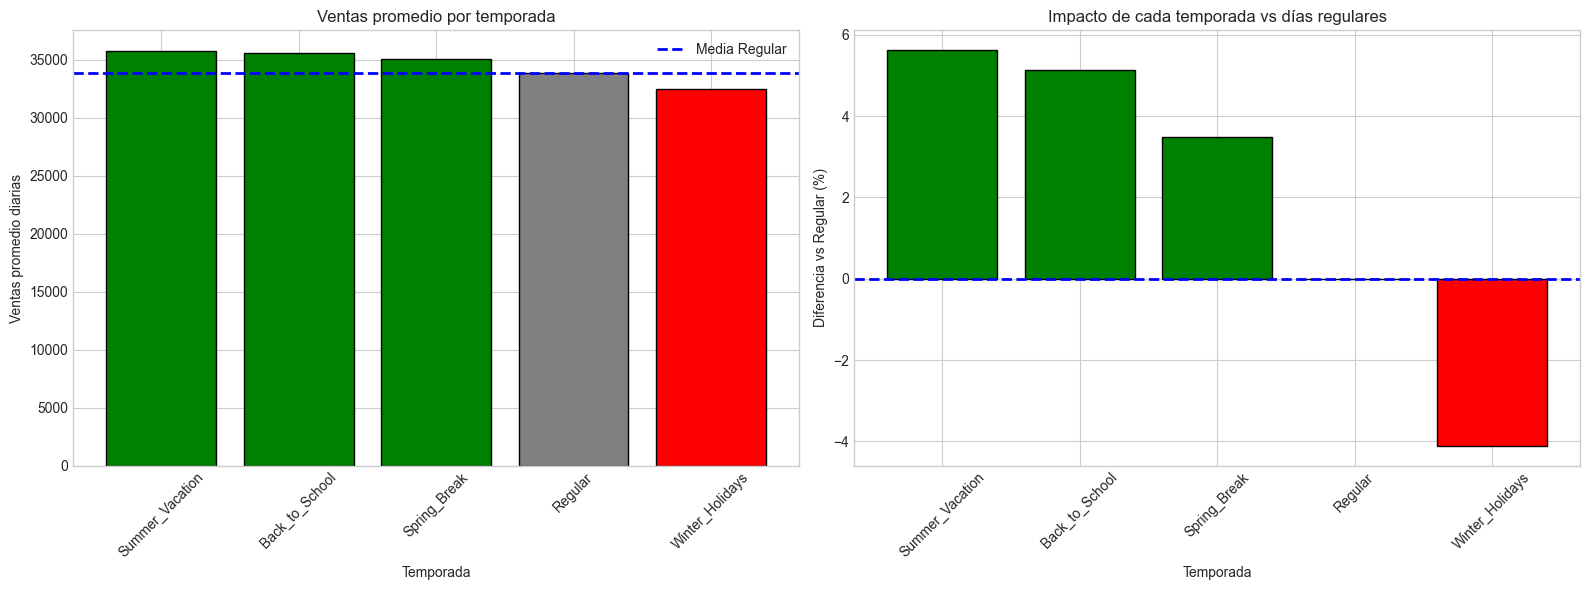

In [25]:
# Visualización resumen
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras: Ventas promedio por temporada
colores = ['green' if x > media_regular else 'red' if x < media_regular else 'gray' 
           for x in resumen['Ventas_Media_Diaria']]
axes[0].bar(resumen['Temporada'], resumen['Ventas_Media_Diaria'], color=colores, edgecolor='black')
axes[0].axhline(y=media_regular, color='blue', linestyle='--', linewidth=2, label='Media Regular')
axes[0].set_xlabel('Temporada')
axes[0].set_ylabel('Ventas promedio diarias')
axes[0].set_title('Ventas promedio por temporada')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Gráfico de barras: Diferencia porcentual
colores_diff = ['green' if x > 0 else 'red' for x in resumen['Diferencia_vs_Regular_%']]
axes[1].bar(resumen['Temporada'], resumen['Diferencia_vs_Regular_%'], color=colores_diff, edgecolor='black')
axes[1].axhline(y=0, color='blue', linestyle='--', linewidth=2)
axes[1].set_xlabel('Temporada')
axes[1].set_ylabel('Diferencia vs Regular (%)')
axes[1].set_title('Impacto de cada temporada vs días regulares')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

IMPACTO POR TEMPORADA Y CATEGORÍA


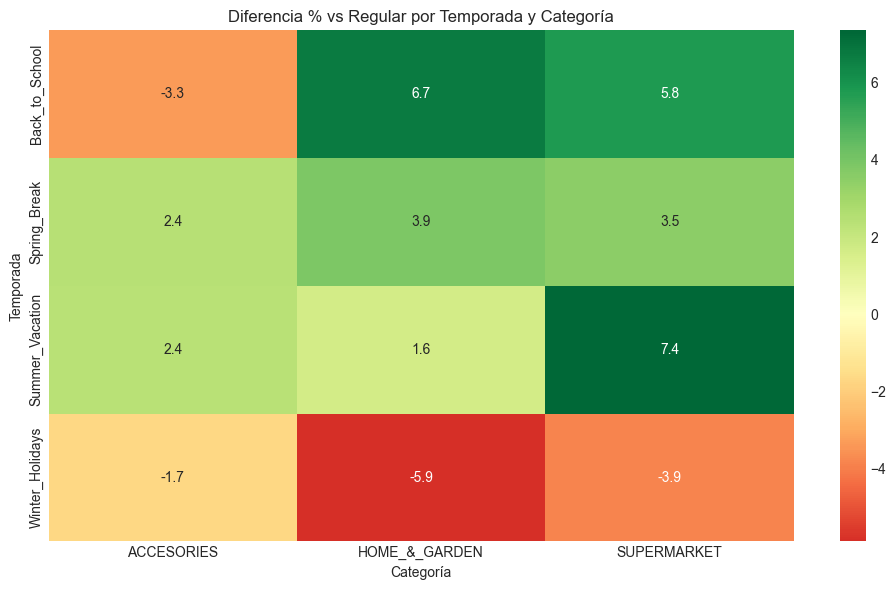

Categoría        ACCESORIES  HOME_&_GARDEN  SUPERMARKET
Temporada                                              
Back_to_School        -3.30           6.70         5.80
Spring_Break           2.40           3.90         3.50
Summer_Vacation        2.40           1.60         7.40
Winter_Holidays       -1.70          -5.90        -3.90


In [26]:
# Heatmap: Temporada × Categoría
print("="*60)
print("IMPACTO POR TEMPORADA Y CATEGORÍA")
print("="*60)

# Crear tabla pivote
pivot_data = []
for season in ['Spring_Break', 'Summer_Vacation', 'Back_to_School', 'Winter_Holidays']:
    df_season = df[df['season'] == season]
    season_por_cat = df_season.groupby(['date', 'category'])['sales'].sum().reset_index()
    season_cat_media = season_por_cat.groupby('category')['sales'].mean()
    
    for cat in season_cat_media.index:
        diff_pct = ((season_cat_media[cat] / regular_cat_media[cat]) - 1) * 100
        pivot_data.append({'Temporada': season, 'Categoría': cat, 'Diferencia_%': diff_pct})

pivot_df = pd.DataFrame(pivot_data)
pivot_table = pivot_df.pivot(index='Temporada', columns='Categoría', values='Diferencia_%')

# Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Diferencia % vs Regular por Temporada y Categoría')
plt.tight_layout()
plt.show()

print(pivot_table.round(1))

## 11. Conclusiones

### Hallazgos principales

**Impacto por temporada (ordenado de mayor a menor):**

| Temporada | Días | Ventas Media Diaria | Diferencia vs Regular |
|-----------|------|---------------------|----------------------|
| Summer Vacation | 220 | 35,739 | **+5.6%** |
| Back to School | 315 | 35,573 | **+5.1%** |
| Spring Break | 276 | 35,018 | **+3.5%** |
| Regular | 867 | 33,837 | 0% (baseline) |
| Winter Holidays | 235 | 32,448 | **-4.1%** |

**Hallazgo clave:** Winter Holidays es la **única temporada con impacto negativo**, lo cual es contraintuitivo para retail. Esto se explica por:
- Christmas con tiendas cerradas (78 ventas totales en 5 años)
- Thanksgiving con ventas reducidas (105,650 vs promedio ~170,000)
- El efecto negativo de estos días arrastra el promedio de toda la temporada

**Categorías más afectadas por temporada:**

| Temporada | ACCESORIES | HOME_&_GARDEN | SUPERMARKET |
|-----------|------------|---------------|-------------|
| Summer Vacation | +2.4% | +1.6% | **+7.4%** |
| Back to School | **-3.3%** | **+6.7%** | +5.8% |
| Spring Break | +2.4% | +3.9% | +3.5% |
| Winter Holidays | -1.7% | **-5.9%** | -3.9% |

**Insights por temporada:**

1. **Summer Vacation (junio - 14 julio):**
   - Mayor impacto positivo (+5.6%)
   - SUPERMARKET lidera con +7.4% (compras para vacaciones, barbacoas, etc.)
   - Consistente año a año (2012-2015 estable en ~36,000-39,000)

2. **Back to School (15 julio - 15 septiembre):**
   - Segundo mayor impacto (+5.1%)
   - HOME_&_GARDEN destaca con +6.7% (decoración, organización del hogar)
   - **ACCESORIES cae -3.3%** (sorprendente, quizás no venden material escolar típico)
   - Crecimiento constante año a año

3. **Spring Break (marzo - 15 abril):**
   - Impacto moderado (+3.5%)
   - Efecto uniforme en las 3 categorías (~2-4%)
   - Mayor variabilidad entre años (de 25,000 en 2011 a 42,000 en 2016)

4. **Winter Holidays (15 nov - 31 dic):**
   - **Única temporada negativa (-4.1%)**
   - HOME_&_GARDEN es la más afectada (-5.9%)
   - Los eventos dentro de la temporada explican el efecto:
     - NewYears_Eve: 180,107 (relativamente alto)
     - Cyber_Monday: 152,262 (bajo)
     - Black_Friday: 127,429 (muy bajo)
     - Thanksgiving: 105,650 (bajo)
     - Christmas: 78 (tiendas cerradas)

**Consistencia año a año:**
- Todas las temporadas muestran **crecimiento consistente** año a año (siguiendo la tendencia general)
- El patrón relativo (qué temporada es mejor/peor) se mantiene estable
- 2016 muestra los valores más altos en todas las temporadas (continuación de tendencia)

**Test estadístico:**
- ANOVA confirma diferencias significativas (F=9.89, p-valor < 0.001)
- Las diferencias entre temporadas son reales, no aleatorias

### Recomendaciones para Feature Engineering

**Features de temporada a crear:**
```python
# Features binarias
'is_spring_break'      # 1 marzo - 15 abril
'is_summer_vacation'   # 1 junio - 14 julio
'is_back_to_school'    # 15 julio - 15 septiembre
'is_winter_holidays'   # 15 noviembre - 31 diciembre

# Feature categórica
'season'  # ['Regular', 'Spring_Break', 'Summer_Vacation', 'Back_to_School', 'Winter_Holidays']

# Features de posición dentro de la temporada
'days_into_season'       # Días desde inicio de la temporada actual
'days_until_season_end'  # Días hasta fin de la temporada actual
```

**Interacciones sugeridas:**
- `season × category`: El efecto de la temporada varía significativamente por categoría
- `season × dayofweek`: Verificar si el efecto fin de semana cambia por temporada
- `is_winter_holidays × is_event`: Para capturar el efecto especial de Christmas/Thanksgiving

**Consideraciones especiales para Winter Holidays:**
- Crear variable `is_store_likely_closed` para Christmas
- Considerar excluir Christmas del entrenamiento o tratarlo como caso especial
- El modelo debe aprender que Winter Holidays ≠ aumento de ventas (contrario a otros retailers)

### Implicaciones para el negocio

1. **Inventario:**
   - Aumentar stock de SUPERMARKET en verano (+7.4%)
   - Aumentar stock de HOME_&_GARDEN en Back to School (+6.7%)
   - **Reducir expectativas** para Winter Holidays (no es temporada alta)

2. **Marketing:**
   - Enfocar campañas de ACCESORIES fuera de Back to School (donde caen)
   - Winter Holidays requiere estrategia diferente: el efecto "compras navideñas" no aplica igual

3. **Operaciones:**
   - Summer y Back to School requieren más personal (mayor volumen)
   - Winter Holidays puede tener reducción de horarios sin impacto negativo